#***KNN***

This notebook trains and evaluates a KNN model for underwater acoustic classification.

Evaluation metrics:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Import libraries:

In [ ]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

import joblib

Mount Drive:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Define Path:

In [ ]:
PROJECT_DIR = Path("/content/drive/MyDrive/Underwater Audio Data")

DATA_DIR = PROJECT_DIR / "scaled"

MODEL_DIR = PROJECT_DIR / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

Load Data:

In [ ]:
X_train = pd.read_csv(DATA_DIR / "X_train_scaled.csv")

X_test = pd.read_csv(DATA_DIR / "X_test_scaled.csv")

y_train = pd.read_csv(DATA_DIR / "y_train.csv")

y_test = pd.read_csv(DATA_DIR / "y_test.csv")

Converts labels to series:

In [ ]:
y_train = y_train.squeeze()

y_test = y_test.squeeze()

Verify Shape:

In [ ]:
print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print()

print("Training Labels :", y_train.shape)

print("Testing Labels :", y_test.shape)

Training Features : (6086, 155)
Testing Features : (1811, 155)

Training Labels : (6086,)
Testing Labels : (1811,)


Create the model:

In [ ]:
model = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    metric="minkowski"
)

Train the model:

In [ ]:
model.fit(X_train, y_train)

KNeighborsClassifier(weights='distance')

Make predictions:

In [ ]:
y_pred = model.predict(X_test)

Accuracy:

In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8796


Precision, Recall, F1-score:

In [ ]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

Precision : 0.8770
Recall    : 0.8796
F1 Score  : 0.8723


Classification Report:

In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

    Ambience       0.83      0.57      0.68       360
  Biological       0.86      0.98      0.91       500
     Vessels       0.90      0.94      0.92       951

    accuracy                           0.88      1811
   macro avg       0.87      0.83      0.84      1811
weighted avg       0.88      0.88      0.87      1811



Confusion matrix:

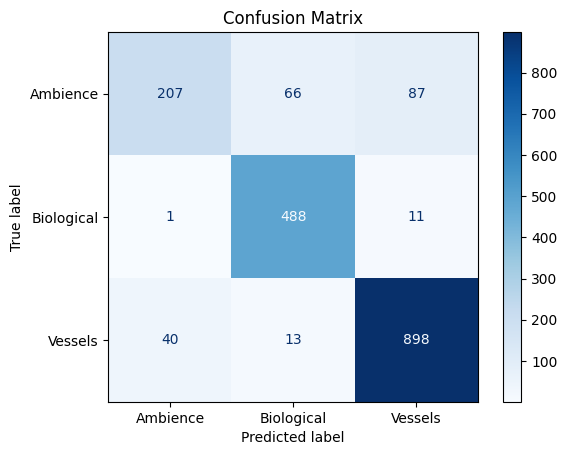

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

Saave the model:

In [ ]:
joblib.dump(model, MODEL_DIR / "knn_model.pkl")

print("Model saved successfully.")

Model saved successfully.


FINAL SUMMARY

In [17]:
print("=" * 60)

print("KNN COMPLETED")

print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print()

print("Model saved to:")

print(MODEL_DIR / "KNN.pkl")

KNN COMPLETED
Accuracy : 0.8796
Precision: 0.8770
Recall   : 0.8796
F1 Score : 0.8723

Model saved to:
/content/drive/MyDrive/Underwater Audio Data/models/KNN.pkl
